In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
"""
Polynomial Regression
It is regression algo as that models the relationship between dependent (y) and independent (x) as nth degree polynomial.
y = b0 + b1x + b2x^2 + b3x^3 + ......+bnx^n + C
"""

In [5]:
dataset = pd.read_csv("Ice_cream selling data.csv")
dataset.head(3)

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001


In [6]:
dataset.shape

(49, 2)

In [7]:
dataset.isnull().sum()

Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64

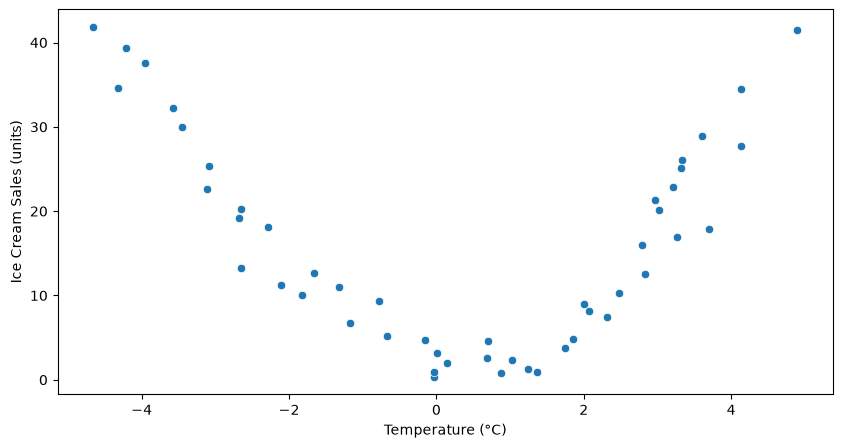

In [11]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Temperature (°C)",y="Ice Cream Sales (units)",data=dataset)
plt.show()

In [12]:
dataset.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [14]:
x = dataset.iloc[:,:-1]
y = dataset["Ice Cream Sales (units)"]
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.25 , random_state = 42)

In [16]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train , y_train)
lr.score(x_test,y_test)*100

-24.630892029337303

In [17]:
lr.coef_

array([-1.00964836])

In [18]:
lr.intercept_

np.float64(17.247110624898774)

In [19]:
lr.predict(x_test)

array([19.08359799, 13.50731512, 13.07369502, 13.60149407, 18.02790203,
       16.21304815, 16.3637642 , 16.54681966, 15.37870391, 17.39818922,
       19.37935639, 20.86019151, 14.90614879])

In [20]:
lr.predict(x_test) == y_test


13    False
45    False
47    False
44    False
17    False
27    False
26    False
25    False
31    False
19    False
12    False
4     False
34    False
Name: Ice Cream Sales (units), dtype: bool

In [25]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)

x_poly = poly.fit_transform(x)

lr = LinearRegression()
lr.fit(x_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. ,-0.82, 1.83]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.952
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[44.1 ,18.69, 0. ]"


C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


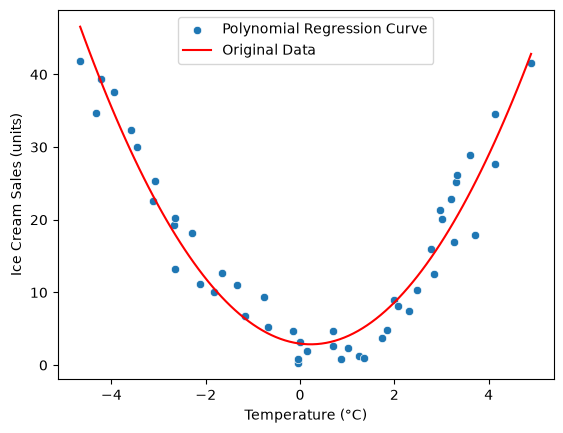

In [26]:
sns.scatterplot(
    x="Temperature (°C)",
    y="Ice Cream Sales (units)",
    data=dataset
)

# Sort x values for a smooth curve
x_grid = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

plt.plot(
    x_grid,
    lr.predict(poly.transform(x_grid)),
    c="red"
)

plt.legend(["Polynomial Regression Curve", "Original Data"])
plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales (units)")
plt.show()